In [4]:
import cv2
import os
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import numpy as np
from pygame import mixer
import time
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical


In [6]:
# Define paths for your dataset of eye images
open_eye_dir = 'C:/ALL/Project Final year/eye and mouth ML HAAR/dataset_new/train/open_eyes'
closed_eye_dir = 'C:/ALL/Project Final year/eye and mouth ML HAAR/dataset_new/train/closed_eyes'

# Prepare lists to store images and labels
eye_images = []
eye_labels = []

# Load open eye images and assign label 1
for file in os.listdir(open_eye_dir):
    img = cv2.imread(os.path.join(open_eye_dir, file), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (24, 24))  # Resize to (24, 24) as per model input
    eye_images.append(img)
    eye_labels.append(1)

# Load closed eye images and assign label 0
for file in os.listdir(closed_eye_dir):
    img = cv2.imread(os.path.join(closed_eye_dir, file), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (24, 24))
    eye_images.append(img)
    eye_labels.append(0)

# Convert to numpy arrays
eye_images = np.array(eye_images).reshape(-1, 24, 24, 1)  # Add channel dimension
eye_labels = np.array(eye_labels)

# Normalize the images
eye_images = eye_images / 255.0

# One-hot encode the labels (binary classification)
eye_labels = to_categorical(eye_labels)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(eye_images, eye_labels, test_size=0.2, random_state=42)


In [7]:
# Create a new Sequential model
model = Sequential()

# Add convolutional layers
model.add(Conv2D(64, (3, 3), activation='relu', input_shape=(24, 24, 1)))  # 1 for grayscale images
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())

# Fully connected layer
model.add(Dense(128, activation='relu'))

# Output layer with 2 nodes (Open, Closed) using softmax activation
model.add(Dense(2, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 22, 22, 64)        640       
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 11, 11, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 9, 9, 64)          36928     
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 4, 4, 64)          0         
 g2D)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 1024)              0         
                                                                 
 dense_2 (Dense)             (None, 128)              

In [8]:
# Train the model on the training data
history = model.fit(X_train, y_train, epochs=30, validation_data=(X_test, y_test), batch_size=32)

# Save the model after training
model.save('models/eye_state_model.h5')


Epoch 1/30
31/31 [==============================] - 2s 27ms/step - loss: 0.4978 - accuracy: 0.7862 - val_loss: 0.3098 - val_accuracy: 0.8623
Epoch 2/30
31/31 [==============================] - 1s 20ms/step - loss: 0.2559 - accuracy: 0.8997 - val_loss: 0.1730 - val_accuracy: 0.9393
Epoch 3/30
31/31 [==============================] - 1s 20ms/step - loss: 0.1743 - accuracy: 0.9372 - val_loss: 0.1387 - val_accuracy: 0.9393
Epoch 4/30
31/31 [==============================] - 1s 20ms/step - loss: 0.1371 - accuracy: 0.9443 - val_loss: 0.1189 - val_accuracy: 0.9676
Epoch 5/30
31/31 [==============================] - 1s 20ms/step - loss: 0.1065 - accuracy: 0.9595 - val_loss: 0.0976 - val_accuracy: 0.9555
Epoch 6/30
31/31 [==============================] - 1s 20ms/step - loss: 0.1003 - accuracy: 0.9635 - val_loss: 0.0930 - val_accuracy: 0.9514
Epoch 7/30
31/31 [==============================] - 1s 22ms/step - loss: 0.0808 - accuracy: 0.9696 - val_loss: 0.0743 - val_accuracy: 0.9636
Epoch 8/30
31

C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


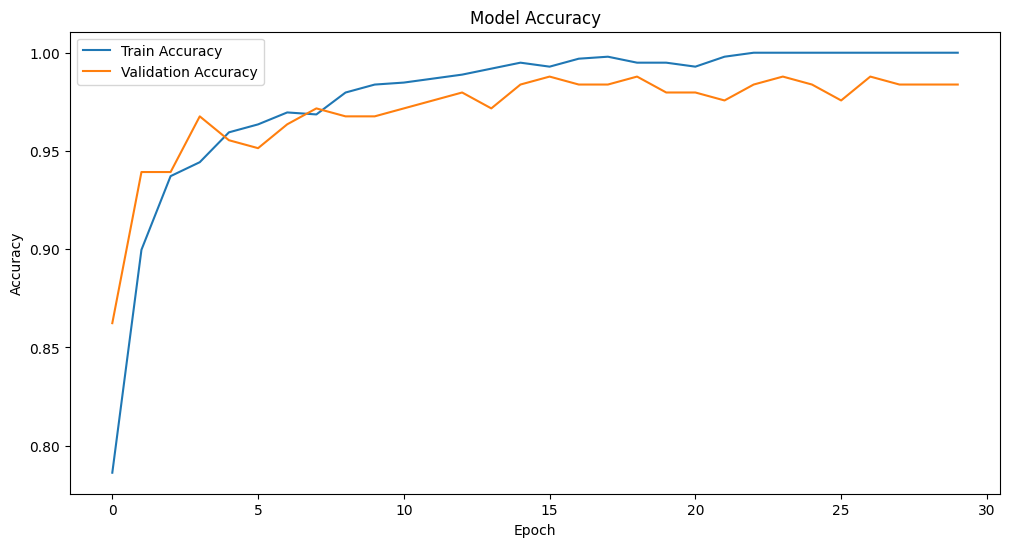

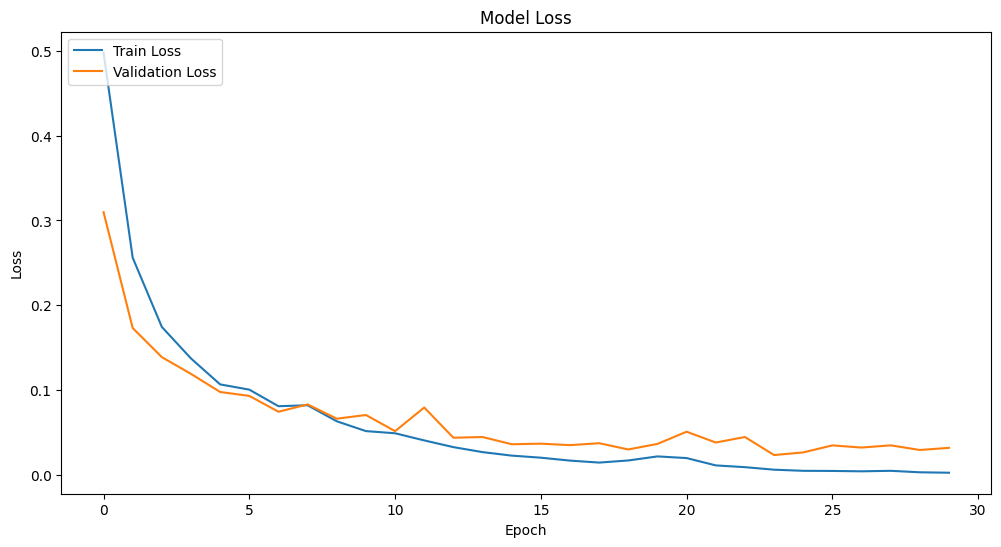

In [9]:
# Plot accuracy and loss graph
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

# Optionally, plot the loss as well
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()


In [10]:
# Load the trained model
model = load_model('models/eye_state_model.h5')


In [11]:
# Initialize webcam and declare variables
capture = cv2.VideoCapture(0)

if not capture.isOpened():
    raise IOError("Cannot open webcam")

font = cv2.FONT_HERSHEY_COMPLEX_SMALL
counter = 0
detection_time = 0  # Time spent with eyes closed
thick = 2
right_eye_pred = [99]
left_eye_pred = [99]
path = os.getcwd()

# Initialize the beep sound
mixer.init()
alarm_sound = mixer.Sound('alarm.wav')
